# **Univariate Forecasting**

https://huggingface.co/amazon/chronos-2

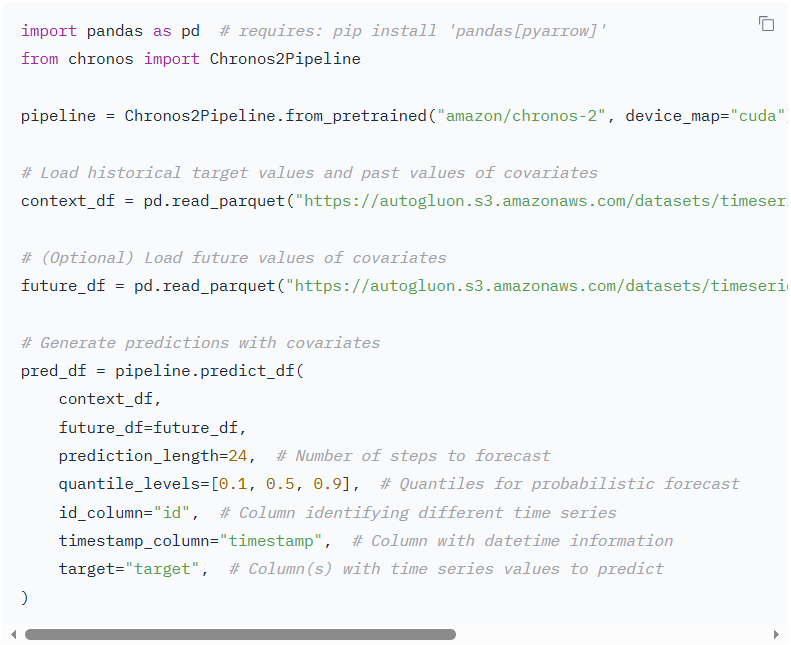

In [2]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
import matplotlib.pyplot as plt
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
import numpy as np
import torch
from chronos import Chronos2Pipeline
from transformers import utils


utils.logging.disable_progress_bar()

# 1. Load the official Chronos-2 pipeline
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda" if torch.cuda.is_available() else "cpu")

# 2. Load the intermediate processed data
context_df = pd.read_csv("context_df.csv")
ground_truth = np.load("horizon_true.npy")
# print(context_df)
# print(ground_truth)

# Ensure the timestamp column is parsed as datetime objects for the API
context_df["timestamp"] = pd.to_datetime(context_df["timestamp"])

# 3. Generate predictions
pred_df = pipeline.predict_df(
    context_df,
    prediction_length=24,  # Number of steps (hours) to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

print(pred_df)

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-f5_gzi_k
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-f5_gzi_k
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 95185d1336e5bfdf50374d44c06ad9e10b303144
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.3.0-py3-none-any.whl size=80095 sha256=87c8dd02dfe378d9149c6e2f28ebd757165a931b3684fc6c91ad134113486b8a
  Stored in directory: /tmp/pip-ephem-wheel-cache-6nn5j732/wheels/b9/a6/b5/75fca7306751a3bc92a63680f861f44a42a8776f6423cf0188
Successfully built chronos-forecasting


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


                  id           timestamp target_name  predictions  \
0       AUS_SA_day_0 2014-01-01 00:00:00      target  1434.628052   
1       AUS_SA_day_0 2014-01-01 01:00:00      target  1296.710205   
2       AUS_SA_day_0 2014-01-01 02:00:00      target  1195.376953   
3       AUS_SA_day_0 2014-01-01 03:00:00      target  1135.552246   
4       AUS_SA_day_0 2014-01-01 04:00:00      target  1116.349976   
...              ...                 ...         ...          ...   
8755  AUS_SA_day_364 2014-12-31 19:00:00      target  1082.481812   
8756  AUS_SA_day_364 2014-12-31 20:00:00      target  1101.730469   
8757  AUS_SA_day_364 2014-12-31 21:00:00      target  1080.017212   
8758  AUS_SA_day_364 2014-12-31 22:00:00      target  1037.906372   
8759  AUS_SA_day_364 2014-12-31 23:00:00      target  1109.468628   

              0.1          0.5          0.9  
0     1366.395752  1434.628052  1500.093872  
1     1199.782959  1296.710205  1394.745483  
2     1072.321655  1195.376953  1

             id dataset        rmse       mape
0  AUS_SA_day_0     AUS  121.145814   7.689633
1  AUS_SA_day_1     AUS  105.616855   7.565347
2  AUS_SA_day_2     AUS   98.006270   8.628990
3  AUS_SA_day_3     AUS  114.419421  11.250906
4  AUS_SA_day_4     AUS   72.165140   5.629392

Summary Statistics
  dataset   rmse_mean  rmse_median    rmse_q1     rmse_q3  mape_mean  \
0     AUS  115.441263    80.845444  53.345923  143.081173   7.521624   

   mape_median   mape_q1   mape_q3  
0     5.411093  3.486871  9.473154  


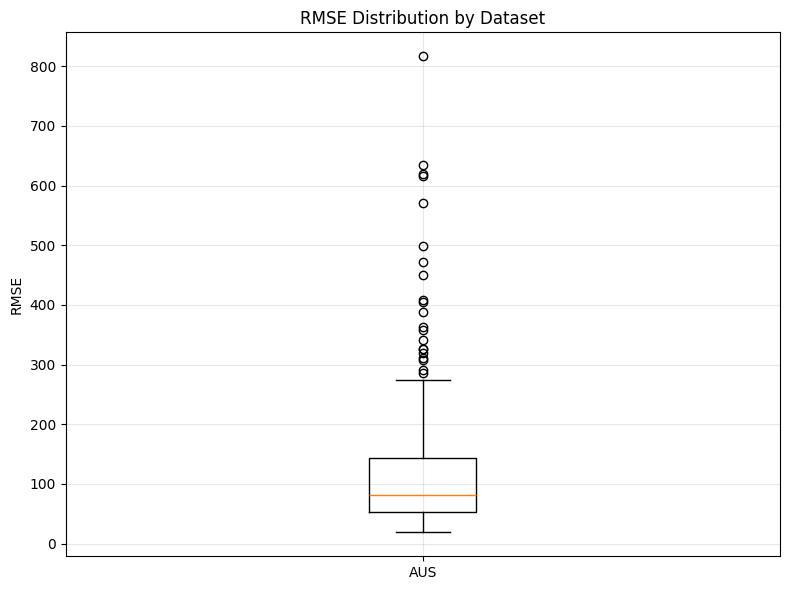

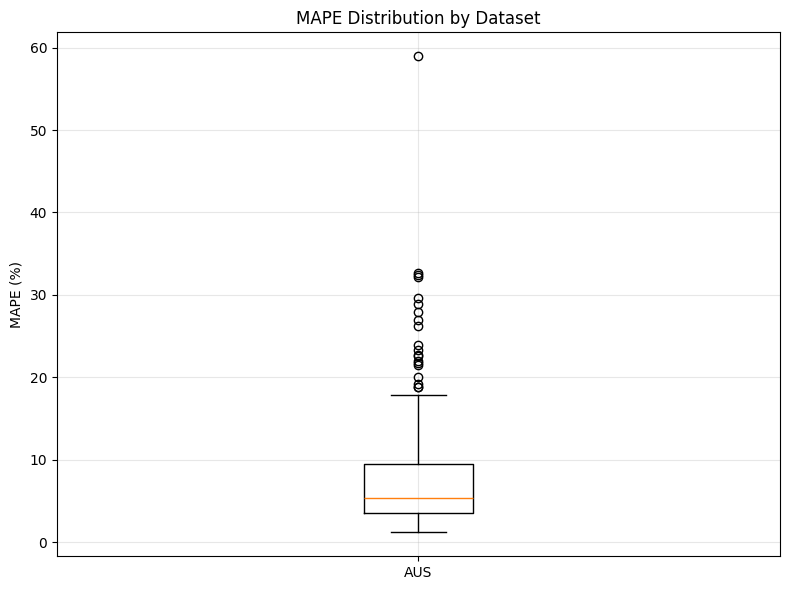


Saved:
- chronos2_individual_metrics.csv
- chronos2_summary_statistics.csv
- rmse_boxplot.png
- mape_boxplot.png


In [4]:
# 4. Extract the Median Predictions
# Group by 'id' to ensure the array shape aligns perfectly with the ground truth matrix
forecast_median = np.array([
    group["predictions"].values for _, group in pred_df.groupby("id", sort=False)
])

# 5. Define Evaluation Metrics
def calculate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Root Mean Squared Error
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return rmse, mape

# 6. Calculate RMSE and MAPE for each forecast instance (each id)
metric_records = []

ids = list(pred_df.groupby("id", sort=False).groups.keys())

for i, ts_id in enumerate(ids):

    y_true = ground_truth[i]
    y_pred = forecast_median[i]

    rmse, mape = calculate_metrics(y_true, y_pred)

    # Dataset identifier:
    # AUS_NSW_day_0 -> AUS
    dataset = ts_id.split("_")[0]

    metric_records.append({
        "id": ts_id,
        "dataset": dataset,
        "rmse": rmse,
        "mape": mape
    })

metrics_df = pd.DataFrame(metric_records)

print(metrics_df.head())

# 7. Summary statistics by dataset
summary_stats = metrics_df.groupby("dataset").agg(
    rmse_mean=("rmse", "mean"),
    rmse_median=("rmse", "median"),
    rmse_q1=("rmse", lambda x: x.quantile(0.25)),
    rmse_q3=("rmse", lambda x: x.quantile(0.75)),

    mape_mean=("mape", "mean"),
    mape_median=("mape", "median"),
    mape_q1=("mape", lambda x: x.quantile(0.25)),
    mape_q3=("mape", lambda x: x.quantile(0.75))
).reset_index()

print("\nSummary Statistics")
print(summary_stats)

summary_stats.to_csv(
    "chronos2_summary_statistics.csv",
    index=False
)

# 8. Boxplot: RMSE
datasets = sorted(metrics_df["dataset"].unique())

rmse_data = [
    metrics_df.loc[metrics_df["dataset"] == ds, "rmse"]
    for ds in datasets
]

plt.figure(figsize=(8, 6))
plt.boxplot(rmse_data, tick_labels=datasets)
plt.ylabel("RMSE")
plt.title("RMSE Distribution by Dataset")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_boxplot.png", dpi=300)
plt.show()

# 9. Boxplot: MAPE
mape_data = [
    metrics_df.loc[metrics_df["dataset"] == ds, "mape"]
    for ds in datasets
]

plt.figure(figsize=(8, 6))
plt.boxplot(mape_data, tick_labels=datasets)
plt.ylabel("MAPE (%)")
plt.title("MAPE Distribution by Dataset")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mape_boxplot.png", dpi=300)
plt.show()

# 10. Save individual metrics
metrics_df.to_csv(
    "chronos2_individual_metrics.csv",
    index=False
)

print("\nSaved:")
print("- chronos2_individual_metrics.csv")
print("- chronos2_summary_statistics.csv")
print("- rmse_boxplot.png")
print("- mape_boxplot.png")